## 0. Chuẩn bị môi trường

Notebook này dùng lại đúng bộ dữ liệu Pima Indians Diabetes như `diabetes_demo.ipynb`, nhưng thay vì train một classifier có giám sát (MLP + BCE), ta train một **Autoencoder** (Encoder + Decoder) một cách tự giám sát: đầu vào cũng chính là mục tiêu (target = X, không dùng nhãn `Outcome` để train).

Encoder nén 8 feature xuống một latent vector nhỏ (2 chiều, để có thể vẽ trực tiếp), Decoder học cách tái tạo lại 8 feature gốc từ latent vector đó. Notebook sẽ:
1. Train autoencoder để tái tạo dữ liệu.
2. Xem sai số tái tạo có khác nhau giữa nhóm `Outcome=0` và `Outcome=1` không (tín hiệu kiểu phát hiện bất thường).
3. Trực quan hoá latent space 2D, tô màu theo nhãn thật.
4. So sánh việc train một classifier nhỏ trên latent 2D so với train trực tiếp trên 8 feature gốc.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))

### Giải thích cell import đầu tiên

Giống hệt `diabetes_demo.ipynb`: bật `autoreload` để tự nạp lại code khi sửa file trong project, và thêm thư mục cha vào `sys.path` để import được `models`/`utils`. Cell này không in ra gì; nếu chạy lỗi thường là do notebook không đứng đúng thư mục gốc project.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from models.autoencoder.model import Autoencoder
from models.MLP.model import MLP
from utils.loss.MSELoss import MSELoss
from utils.loss.BCELoss import BCELoss
from utils.optimizers.Adam import Adam

### Giải thích cell import thư viện

- `Autoencoder` (`models/autoencoder/model.py`): ghép một `Encoder` và một `Decoder`, cả hai được xây từ `Linear` + `ReLU` đã có sẵn trong repo.
- `MLP` được dùng lại ở phần 7 để so sánh classifier train trên latent 2D với classifier train trên 8 feature gốc.
- `MSELoss`: dùng cho bài toán tái tạo (reconstruction), vì input đã được chuẩn hoá (StandardScaler) thành giá trị liên tục, không phải xác suất nhị phân như `BCELoss`.
- `Adam`: optimizer để train cả hai model trong notebook này.

## 1. Load real data (Pima Indians Diabetes)

CSV không có header. Các cột: Pregnancies, Glucose, BloodPressure, SkinThickness,
Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome (0/1).

In [3]:
DATA_PATH = r"D:\Project\Dataset\Medical\pima-indians-diabetes.csv"

data = np.loadtxt(DATA_PATH, delimiter=",")
X = data[:, :-1]
y = data[:, -1:]  # chỉ dùng để tô màu / phân tích sau khi train, không dùng để train autoencoder

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (768, 8) y shape: (768, 1)


### Giải thích cell nạp dữ liệu

Autoencoder là mô hình tự giám sát: nó chỉ cần `X`, không cần `y` để train. `y` (nhãn `Outcome`) được giữ lại ở đây chỉ để dùng sau khi train xong, nhằm kiểm tra xem sai số tái tạo hoặc latent space có phản ánh được sự khác biệt giữa hai nhóm bệnh nhân hay không.

## 2. Train/test split + feature scaling

Giống `diabetes_demo.ipynb`: fit `StandardScaler` trên train rồi áp dụng cho test, tránh rò rỉ thông tin. Việc chuẩn hoá đặc biệt quan trọng ở đây vì target của autoencoder chính là `X` đã scale — nếu không scale, các cột có phương sai lớn (như Insulin) sẽ chiếm phần lớn MSE loss và lấn át các cột còn lại.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


### Giải thích cell chia train/test và chuẩn hoá

Kết quả chia giống hệt `diabetes_demo.ipynb` (614 mẫu train, 154 mẫu test, cùng `random_state=42` và `stratify=y`), để hai notebook có thể so sánh kết quả với nhau một cách công bằng.

## 3. Xây dựng Autoencoder, loss, optimizer

- `latent_dim=2`: cố tình chọn rất nhỏ để có thể vẽ trực tiếp latent space lên mặt phẳng 2D, đổi lại là nén rất mạnh (8 → 2).
- `hidden_dims=[6]`: một lớp ẩn ở cả Encoder và Decoder, đối xứng nhau (Decoder tự động dùng `hidden_dims` đảo ngược).
- Lớp cuối của Encoder (chính là latent code) **không** có activation — nếu dùng ReLU ở đây, latent space sẽ bị ép về góc phần tư không âm, làm mất khả năng biểu diễn và khiến việc vẽ 2D bị dồn vào một góc.

In [5]:
np.random.seed(42)
model = Autoencoder(input_dim=X_train.shape[1], hidden_dims=[6], latent_dim=2)
loss_fn = MSELoss()
optimizer = Adam(model.parameters(), lr=0.01)

### Giải thích cell khởi tạo mô hình

Không có output text. `model.parameters()` gộp tham số của cả Encoder lẫn Decoder để Adam cập nhật đồng thời khi backward chạy qua toàn bộ autoencoder.

## 4. Train (tái tạo X_train từ chính nó, full-batch)

Target chính là `X_train` — đây là điểm khác biệt so với bài toán classification: `loss_fn(recon, X_train)` thay vì so với nhãn `y`.

In [6]:
n_epochs = 300
loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    recon = model(X_train)
    loss = loss_fn(recon, X_train)
    loss_history.append(loss)

    grad_loss = loss_fn.backward()
    model.backward(grad_loss)
    optimizer.step()

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:4d} — reconstruction MSE: {loss:.4f}")

Epoch    0 — reconstruction MSE: 1.8208
Epoch   50 — reconstruction MSE: 0.6915
Epoch  100 — reconstruction MSE: 0.5720
Epoch  150 — reconstruction MSE: 0.5148
Epoch  200 — reconstruction MSE: 0.4719
Epoch  250 — reconstruction MSE: 0.4572
Epoch  299 — reconstruction MSE: 0.4493


### Giải thích cell train mô hình

Loss giảm dần qua các epoch cho thấy Decoder ngày càng tái tạo tốt hơn từ latent vector 2 chiều do Encoder tạo ra. Vì đây là bài toán tái tạo (không phải phân loại), loss sẽ không tiến về 0 hoàn toàn — với `latent_dim=2` cho 8 feature, một phần thông tin chắc chắn bị mất trong quá trình nén.

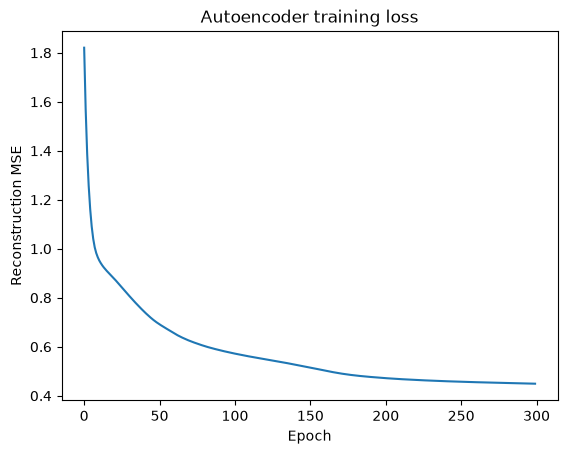

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder training loss")
plt.show()

### Giải thích cell vẽ loss

Đường cong đi xuống và ổn định dần cho thấy quá trình train hội tụ. Khác với `diabetes_demo.ipynb` (BCE loss cho classification), ở đây trục y là MSE loss của bài toán reconstruction.

## 5. Đánh giá tái tạo trên tập test

Sau khi train xong, kiểm tra sai số tái tạo trên test set, đồng thời tách riêng theo nhóm `Outcome` để xem autoencoder có "khó" tái tạo nhóm bệnh nhân dương tính hơn không — nếu có, đó là một tín hiệu kiểu phát hiện bất thường (anomaly detection): autoencoder học chủ yếu từ phân bố chung của dữ liệu, nên các mẫu "khác thường" (ở đây là nhóm dương tính, chiếm thiểu số ~35%) thường có sai số tái tạo cao hơn.

In [8]:
recon_test = model(X_test)
test_mse = loss_fn(recon_test, X_test)

per_sample_mse = ((recon_test - X_test) ** 2).mean(axis=1)
mse_class0 = per_sample_mse[y_test.ravel() == 0].mean()
mse_class1 = per_sample_mse[y_test.ravel() == 1].mean()

print(f"Test reconstruction MSE (toàn bộ): {test_mse:.4f}")
print(f"Reconstruction MSE trung bình — Outcome=0: {mse_class0:.4f}")
print(f"Reconstruction MSE trung bình — Outcome=1: {mse_class1:.4f}")

Test reconstruction MSE (toàn bộ): 0.5171
Reconstruction MSE trung bình — Outcome=0: 0.4598
Reconstruction MSE trung bình — Outcome=1: 0.6233


### Giải thích cell đánh giá tái tạo

Cách đọc: `per_sample_mse` là sai số tái tạo (MSE) tính riêng cho từng mẫu test, sau đó lấy trung bình theo từng nhóm nhãn. Nếu MSE của nhóm `Outcome=1` cao hơn rõ rệt so với nhóm `Outcome=0`, điều đó gợi ý autoencoder — dù chưa từng thấy nhãn khi train — vẫn học được một biểu diễn mà nhóm bệnh nhân dương tính "lệch" hơn so với phần còn lại của dữ liệu.

## 6. Trực quan hoá latent space 2D

Vì `latent_dim=2`, có thể vẽ trực tiếp latent vector của từng mẫu test lên mặt phẳng, tô màu theo nhãn thật để xem hai nhóm có tách biệt phần nào trong không gian nén hay không (autoencoder không được cho biết nhãn khi train).

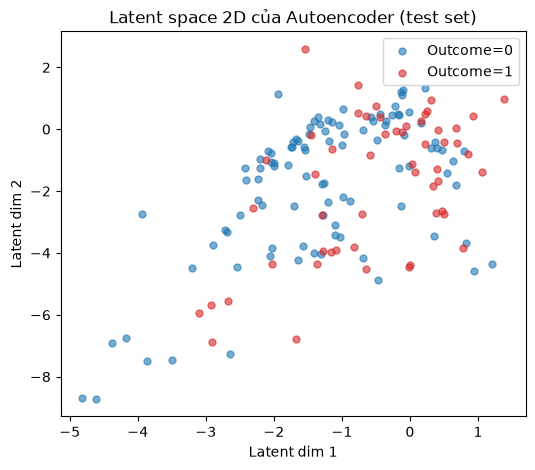

In [9]:
latent_test = model.encode(X_test)

plt.figure(figsize=(6, 5))
for label, color, name in [(0, "tab:blue", "Outcome=0"), (1, "tab:red", "Outcome=1")]:
    mask = y_test.ravel() == label
    plt.scatter(latent_test[mask, 0], latent_test[mask, 1], c=color, label=name, alpha=0.6, s=25)
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("Latent space 2D của Autoencoder (test set)")
plt.legend()
plt.show()

### Giải thích cell trực quan hoá latent space

Mỗi điểm là một bệnh nhân trong tập test, vị trí là latent vector 2 chiều do Encoder tạo ra (không dùng nhãn khi train). Nếu hai màu tách nhau thành từng vùng tương đối rõ, nghĩa là chỉ với thông tin tự giám sát (tái tạo dữ liệu), Encoder vẫn vô tình học được một biểu diễn có liên quan đến nhãn thật — đây chính là giá trị thực dụng của autoencoder: giảm chiều dữ liệu trong khi giữ lại cấu trúc quan trọng.

## 7. So sánh: classifier train trên latent 2D vs train trên 8 feature gốc

Dùng lại `MLP` đã có trong repo để train hai classifier nhỏ:
- Một train trực tiếp trên latent 2D lấy từ Encoder đã train ở trên (đóng băng Encoder, chỉ dùng để trích feature).
- Một train trên 8 feature gốc (giống cách tiếp cận của `diabetes_demo.ipynb`), để làm baseline so sánh.

In [10]:
def train_eval_mlp(X_tr, y_tr, X_te, y_te, hidden_dims, epochs=300, lr=0.01, seed=0):
    np.random.seed(seed)
    net = MLP(input_dim=X_tr.shape[1], hidden_dims=hidden_dims, output_dim=1, activation='sigmoid')
    bce = BCELoss()
    opt = Adam(net.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        pred = net(X_tr)
        bce(pred, y_tr)
        opt_grad = bce.backward()
        net.backward(opt_grad)
        opt.step()
    test_pred = net(X_te)
    return ((test_pred >= 0.5).astype(int) == y_te).mean()

latent_train = model.encode(X_train)
acc_latent = train_eval_mlp(latent_train, y_train, latent_test, y_test, hidden_dims=[8])
acc_raw = train_eval_mlp(X_train, y_train, X_test, y_test, hidden_dims=[16, 8])

print(f"Test accuracy — MLP trên latent 2D (nén từ Autoencoder): {acc_latent:.4f}")
print(f"Test accuracy — MLP trên 8 feature gốc (baseline):        {acc_raw:.4f}")

Test accuracy — MLP trên latent 2D (nén từ Autoencoder): 0.6623
Test accuracy — MLP trên 8 feature gốc (baseline):        0.7338


### Giải thích cell so sánh classifier

Baseline "8 feature gốc" dùng cùng kiến trúc MLP như `diabetes_demo.ipynb` (`hidden_dims=[16, 8]`), nên accuracy ở đây nên gần với kết quả 0.6818 đã thấy ở notebook đó (có thể lệch chút do random init khác). Classifier trên latent 2D thường đạt accuracy thấp hơn — điều này hợp lý: nén 8 chiều xuống 2 chiều chắc chắn mất thông tin. Điểm đáng chú ý không phải là latent 2D "thắng" baseline, mà là nó vẫn giữ được phần lớn tín hiệu phân loại dù bị nén tới 4 lần, cho thấy Autoencoder đã học được một biểu diễn cô đọng nhưng vẫn hữu ích.

## 8. Xem thử vài mẫu: dữ liệu gốc vs dữ liệu tái tạo

Lấy vài mẫu test, đưa qua Encoder rồi Decoder, sau đó `inverse_transform` để so sánh trên đơn vị gốc (dễ đọc hơn là so sánh trên giá trị đã chuẩn hoá).

In [11]:
feature_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                  "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

sample_idx = [0, 1, 2]
recon_sample = model(X_test[sample_idx])

original_units = scaler.inverse_transform(X_test[sample_idx])
recon_units = scaler.inverse_transform(recon_sample)

for i, idx in enumerate(sample_idx):
    print(f"Sample {i+1} (Outcome={int(y_test[idx, 0])}):")
    for name, orig, rec in zip(feature_names, original_units[i], recon_units[i]):
        print(f"  {name:<25s} gốc={orig:8.2f}   tái tạo={rec:8.2f}")
    print()

Sample 1 (Outcome=0):
  Pregnancies               gốc=    7.00   tái tạo=    7.35
  Glucose                   gốc=  159.00   tái tạo=  131.54
  BloodPressure             gốc=   64.00   tái tạo=   61.83
  SkinThickness             gốc=    0.00   tái tạo=    0.86
  Insulin                   gốc=    0.00   tái tạo=   -6.38
  BMI                       gốc=   27.40   tái tạo=   28.96
  DiabetesPedigreeFunction  gốc=    0.29   tái tạo=    0.34
  Age                       gốc=   40.00   tái tạo=   46.45

Sample 2 (Outcome=0):
  Pregnancies               gốc=   10.00   tái tạo=    6.30
  Glucose                   gốc=   68.00   tái tạo=  130.72
  BloodPressure             gốc=  106.00   tái tạo=   81.41
  SkinThickness             gốc=   23.00   tái tạo=   28.58
  Insulin                   gốc=   49.00   tái tạo=   95.95
  BMI                       gốc=   35.50   tái tạo=   36.01
  DiabetesPedigreeFunction  gốc=    0.28   tái tạo=    0.41
  Age                       gốc=   47.00   tái tạo=   4

### Giải thích cell so sánh mẫu gốc vs tái tạo

Với mỗi mẫu, giá trị "tái tạo" là kết quả sau khi đi qua Encoder (nén xuống 2 số) rồi Decoder (giải nén lại thành 8 số). Sai lệch giữa hai cột cho thấy trực quan cái giá phải trả của việc nén dữ liệu: những feature nào Decoder tái tạo lệch nhiều là feature mà latent 2D chưa mã hoá tốt.